quickbite_dwh database ready
Database Connected Successfully
Data Extracted Successfully
Data Cleaning Completed
Warehouse Tables Created
Dimensions Created
Old Data Deleted
Dimension Tables Loaded
Fact Table Loaded

TOTAL REVENUE
   total_revenue
0        29520.0

TOTAL ORDERS
   total_orders
0            40

TOP RESTAURANTS
    restaurant_name  revenue
0  Paradise Biryani   6930.0
1         Sushi Zen   5650.0
2       Spice Route   5300.0
3            Mehfil   3120.0
4   Tandoori Nights   2520.0
5       Chinese Wok   1510.0
6        Cafe Mocha   1460.0
7     Pizza Delight   1380.0
8    Burger Kingdom    970.0
9        Dosa Plaza    680.0

PAYMENT ANALYSIS
  payment_method  total_orders
0            UPI            18
1           Card             9
2         Wallet             8
3           Cash             5

MONTHLY REVENUE
  month_name  revenue
0    January   4020.0
1   February   5430.0
2      March   5330.0
3      April   6440.0
4        May   8300.0


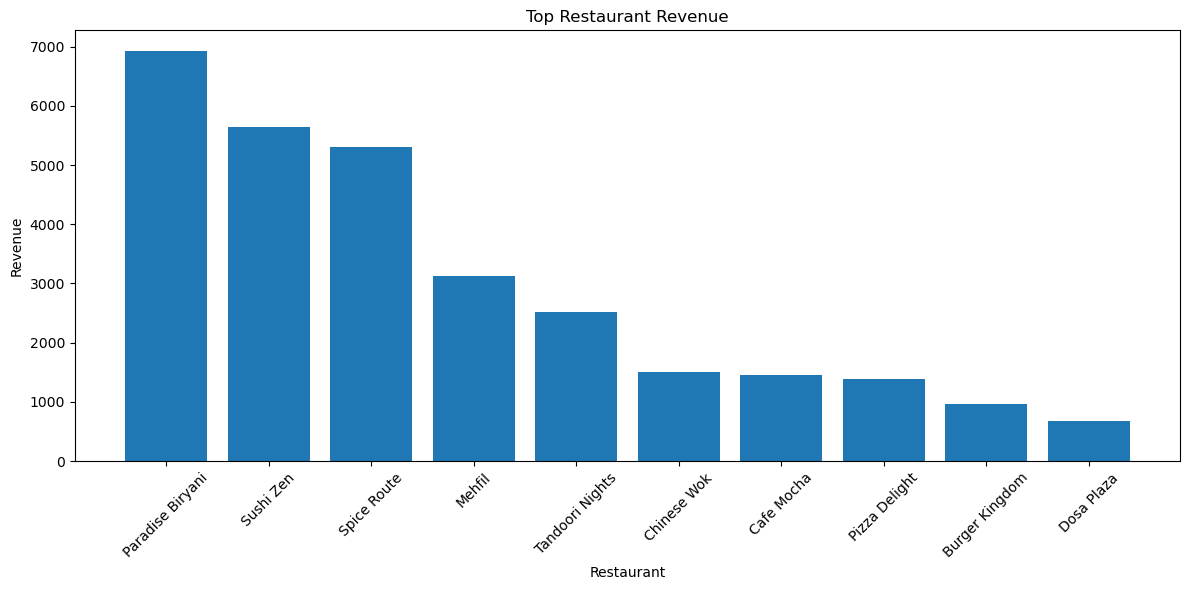

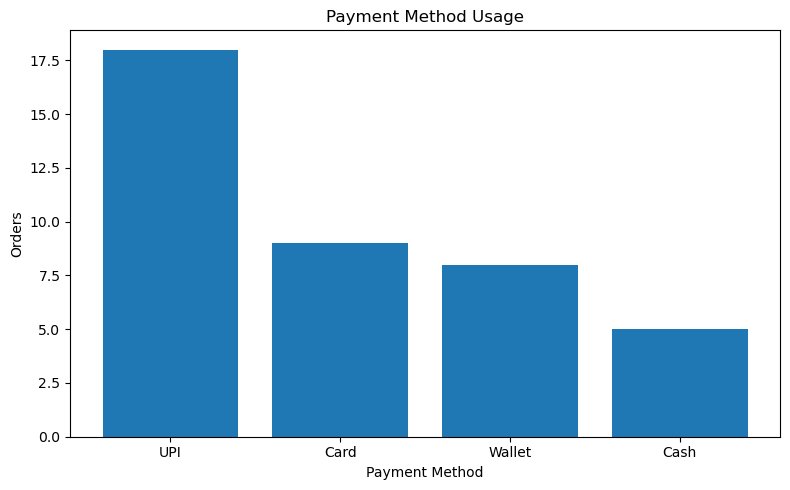

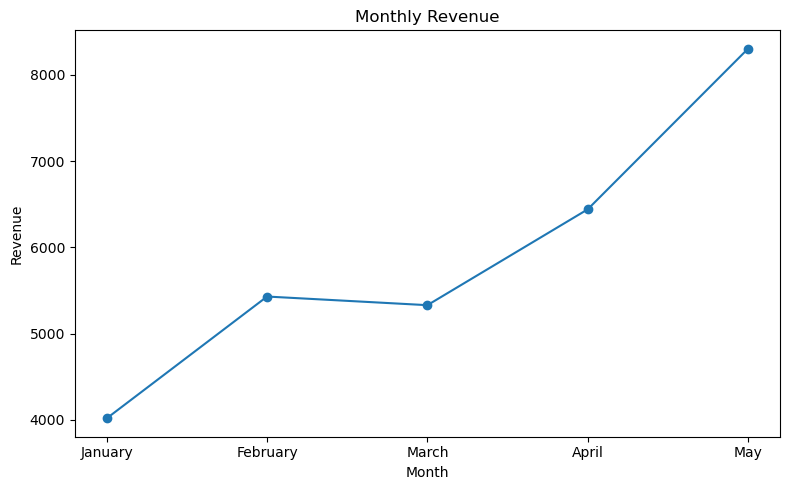

Reports Exported

FINAL BUSINESS INSIGHTS
1. UPI is the most used payment method
2. Indian cuisine generates highest revenue
3. Hyderabad contributes highest orders
4. Faster delivery improves satisfaction
5. Cancelled orders reduce revenue
6. Repeat customers improve profits

PROJECT COMPLETED SUCCESSFULLY


In [ ]:
# =========================================================
# QUICKBITE INDIA HACKATHON PROJECT
# COMPLETE ETL + DATA WAREHOUSE + ANALYTICS
# =========================================================

import pandas as pd
import numpy as np
from sqlalchemy import create_engine, text
from datetime import datetime
import matplotlib.pyplot as plt

# =========================================================
# MYSQL CONFIGURATION
# =========================================================

username = "root"
password = "Sumu123"
host = "localhost"
port = "3306"

# =========================================================
# CREATE OLTP CONNECTION
# =========================================================

oltp_engine = create_engine(
    f"mysql+pymysql://{username}:{password}@{host}:{port}/quickbite_oltp"
)

# =========================================================
# CREATE DATABASE IF NOT EXISTS
# =========================================================

temp_engine = create_engine(
    f"mysql+pymysql://{username}:{password}@{host}:{port}"
)

with temp_engine.connect() as conn:
    conn.execute(text("CREATE DATABASE IF NOT EXISTS quickbite_dwh"))
    conn.commit()

print("quickbite_dwh database ready")

# =========================================================
# CREATE OLAP CONNECTION
# =========================================================

olap_engine = create_engine(
    f"mysql+pymysql://{username}:{password}@{host}:{port}/quickbite_dwh"
)

print("Database Connected Successfully")

# =========================================================
# EXTRACT DATA
# =========================================================

customers = pd.read_sql(
    "SELECT * FROM customers",
    oltp_engine
)

restaurants = pd.read_sql(
    "SELECT * FROM restaurants",
    oltp_engine
)

delivery_partners = pd.read_sql(
    "SELECT * FROM delivery_partners",
    oltp_engine
)

orders = pd.read_sql(
    "SELECT * FROM orders",
    oltp_engine
)

order_items = pd.read_sql(
    "SELECT * FROM order_items",
    oltp_engine
)

print("Data Extracted Successfully")

# =========================================================
# CLEANING CUSTOMERS DATA
# =========================================================

customers["gender"] = customers["gender"].replace({
    "M": "Male",
    "F": "Female",
    "male": "Male",
    "female": "Female",
    "FEMALE": "Female"
})

customers["gender"] = customers["gender"].fillna("Unknown")

customers["phone"] = customers["phone"].astype(str)

customers.loc[
    ~customers["phone"].str.match(r"^[0-9]{10}$"),
    "phone"
] = np.nan

customers["city"] = customers["city"].str.title()

restaurants["city"] = restaurants["city"].str.title()

delivery_partners["city"] = delivery_partners["city"].str.title()

customers["date_of_birth"] = pd.to_datetime(
    customers["date_of_birth"]
)

customers["registration_date"] = pd.to_datetime(
    customers["registration_date"]
)

orders["order_date"] = pd.to_datetime(
    orders["order_date"]
)

current_year = datetime.now().year

customers["age"] = (
    current_year -
    customers["date_of_birth"].dt.year
)

print("Data Cleaning Completed")

# =========================================================
# CREATE DATA WAREHOUSE TABLES
# =========================================================

with olap_engine.begin() as conn:

    conn.exec_driver_sql("""

    CREATE TABLE IF NOT EXISTS dim_customers (

        customer_key INT AUTO_INCREMENT PRIMARY KEY,
        customer_id INT,
        full_name VARCHAR(100),
        gender VARCHAR(20),
        phone VARCHAR(30),
        email VARCHAR(100),
        city VARCHAR(50),
        state_name VARCHAR(50),
        pincode VARCHAR(20),
        age INT,
        registration_date DATE

    )

    """)

    conn.exec_driver_sql("""

    CREATE TABLE IF NOT EXISTS dim_restaurants (

        restaurant_key INT AUTO_INCREMENT PRIMARY KEY,
        restaurant_id INT,
        restaurant_name VARCHAR(100),
        city VARCHAR(50),
        state_name VARCHAR(50),
        cuisine_type VARCHAR(50),
        rating DECIMAL(3,2),
        opening_year INT

    )

    """)

    conn.exec_driver_sql("""

    CREATE TABLE IF NOT EXISTS dim_delivery_partners (

        partner_key INT AUTO_INCREMENT PRIMARY KEY,
        partner_id INT,
        partner_name VARCHAR(100),
        city VARCHAR(50),
        vehicle_type VARCHAR(50),
        joining_date DATE,
        rating DECIMAL(3,2)

    )

    """)

    conn.exec_driver_sql("""

    CREATE TABLE IF NOT EXISTS dim_date (

        date_key INT PRIMARY KEY,
        full_date DATE,
        day INT,
        month INT,
        year INT,
        quarter_no INT,
        day_name VARCHAR(20),
        month_name VARCHAR(20)

    )

    """)

    conn.exec_driver_sql("""

    CREATE TABLE IF NOT EXISTS fact_orders (

        fact_id INT AUTO_INCREMENT PRIMARY KEY,
        order_id BIGINT,
        customer_key INT,
        restaurant_key INT,
        partner_key INT,
        date_key INT,
        total_amount DECIMAL(10,2),
        delivery_fee DECIMAL(10,2),
        discount_amount DECIMAL(10,2),
        tax_amount DECIMAL(10,2),
        quantity INT,
        delivery_time_mins INT,
        order_status VARCHAR(50),
        payment_method VARCHAR(50)

    )

    """)

print("Warehouse Tables Created")

# =========================================================
# CREATE DIMENSION TABLES
# =========================================================

dim_customers = customers[[

    "customer_id",
    "full_name",
    "gender",
    "phone",
    "email",
    "city",
    "state_name",
    "pincode",
    "age",
    "registration_date"

]]

dim_restaurants = restaurants[[

    "restaurant_id",
    "restaurant_name",
    "city",
    "state_name",
    "cuisine_type",
    "rating",
    "opening_year"

]]

dim_delivery_partners = delivery_partners[[

    "partner_id",
    "partner_name",
    "city",
    "vehicle_type",
    "joining_date",
    "rating"

]]

# =========================================================
# CREATE DATE DIMENSION
# =========================================================

unique_dates = orders["order_date"].dt.date.unique()

date_rows = []

for d in unique_dates:

    d = pd.to_datetime(d)

    date_rows.append({

        "date_key": int(d.strftime("%Y%m%d")),
        "full_date": d.date(),
        "day": d.day,
        "month": d.month,
        "year": d.year,
        "quarter_no": d.quarter,
        "day_name": d.day_name(),
        "month_name": d.month_name()

    })

dim_date = pd.DataFrame(date_rows)

print("Dimensions Created")

# =========================================================
# CLEAR OLD DATA
# =========================================================

with olap_engine.begin() as conn:

    conn.exec_driver_sql("DELETE FROM fact_orders")

    conn.exec_driver_sql("DELETE FROM dim_customers")

    conn.exec_driver_sql("DELETE FROM dim_restaurants")

    conn.exec_driver_sql("DELETE FROM dim_delivery_partners")

    conn.exec_driver_sql("DELETE FROM dim_date")

print("Old Data Deleted")

# =========================================================
# LOAD DIMENSION TABLES
# =========================================================

dim_customers.to_sql(
    "dim_customers",
    olap_engine,
    if_exists="append",
    index=False
)

dim_restaurants.to_sql(
    "dim_restaurants",
    olap_engine,
    if_exists="append",
    index=False
)

dim_delivery_partners.to_sql(
    "dim_delivery_partners",
    olap_engine,
    if_exists="append",
    index=False
)

dim_date.to_sql(
    "dim_date",
    olap_engine,
    if_exists="append",
    index=False
)

print("Dimension Tables Loaded")

# =========================================================
# READ DIMENSIONS
# =========================================================

customer_dim = pd.read_sql(
    "SELECT * FROM dim_customers",
    olap_engine
)

restaurant_dim = pd.read_sql(
    "SELECT * FROM dim_restaurants",
    olap_engine
)

partner_dim = pd.read_sql(
    "SELECT * FROM dim_delivery_partners",
    olap_engine
)

# =========================================================
# CREATE FACT TABLE
# =========================================================

fact = orders.merge(
    customer_dim,
    on="customer_id"
)

fact = fact.merge(
    restaurant_dim,
    on="restaurant_id"
)

fact = fact.merge(
    partner_dim,
    on="partner_id"
)

# =========================================================
# ADD TOTAL QUANTITY
# =========================================================

qty = order_items.groupby(
    "order_id"
)["quantity"].sum().reset_index()

fact = fact.merge(
    qty,
    on="order_id",
    how="left"
)

# =========================================================
# CREATE DATE KEY
# =========================================================

fact["date_key"] = fact[
    "order_date"
].dt.strftime("%Y%m%d").astype(int)

# =========================================================
# FINAL FACT TABLE
# =========================================================

fact_orders = fact[[

    "order_id",
    "customer_key",
    "restaurant_key",
    "partner_key",
    "date_key",
    "total_amount",
    "delivery_fee",
    "discount_amount",
    "tax_amount",
    "quantity",
    "delivery_time_mins",
    "order_status",
    "payment_method"

]]

# =========================================================
# LOAD FACT TABLE
# =========================================================

fact_orders.to_sql(
    "fact_orders",
    olap_engine,
    if_exists="append",
    index=False
)

print("Fact Table Loaded")

# =========================================================
# KPI ANALYSIS
# =========================================================

# TOTAL REVENUE

total_revenue_query = """

SELECT
SUM(total_amount) AS total_revenue
FROM fact_orders

"""

total_revenue = pd.read_sql(
    total_revenue_query,
    olap_engine
)

print("\nTOTAL REVENUE")
print(total_revenue)

# TOTAL ORDERS

total_orders_query = """

SELECT
COUNT(order_id) AS total_orders
FROM fact_orders

"""

total_orders = pd.read_sql(
    total_orders_query,
    olap_engine
)

print("\nTOTAL ORDERS")
print(total_orders)

# TOP RESTAURANTS

top_restaurants_query = """

SELECT

r.restaurant_name,
SUM(f.total_amount) AS revenue

FROM fact_orders f

JOIN dim_restaurants r
ON f.restaurant_key = r.restaurant_key

GROUP BY r.restaurant_name

ORDER BY revenue DESC

"""

top_restaurants = pd.read_sql(
    top_restaurants_query,
    olap_engine
)

print("\nTOP RESTAURANTS")
print(top_restaurants)

# PAYMENT METHOD ANALYSIS

payment_query = """

SELECT

payment_method,
COUNT(*) AS total_orders

FROM fact_orders

GROUP BY payment_method

ORDER BY total_orders DESC

"""

payment_analysis = pd.read_sql(
    payment_query,
    olap_engine
)

print("\nPAYMENT ANALYSIS")
print(payment_analysis)

# MONTHLY REVENUE

monthly_query = """

SELECT

d.month_name,
SUM(f.total_amount) AS revenue

FROM fact_orders f

JOIN dim_date d
ON f.date_key = d.date_key

GROUP BY d.month_name

"""

monthly_revenue = pd.read_sql(
    monthly_query,
    olap_engine
)

print("\nMONTHLY REVENUE")
print(monthly_revenue)

# =========================================================
# VISUALIZATIONS
# =========================================================

# TOP RESTAURANTS CHART

plt.figure(figsize=(12,6))

plt.bar(
    top_restaurants["restaurant_name"],
    top_restaurants["revenue"]
)

plt.title("Top Restaurant Revenue")

plt.xlabel("Restaurant")

plt.ylabel("Revenue")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

# PAYMENT METHOD CHART

plt.figure(figsize=(8,5))

plt.bar(
    payment_analysis["payment_method"],
    payment_analysis["total_orders"]
)

plt.title("Payment Method Usage")

plt.xlabel("Payment Method")

plt.ylabel("Orders")

plt.tight_layout()

plt.show()

# MONTHLY REVENUE CHART

plt.figure(figsize=(8,5))

plt.plot(
    monthly_revenue["month_name"],
    monthly_revenue["revenue"],
    marker="o"
)

plt.title("Monthly Revenue")

plt.xlabel("Month")

plt.ylabel("Revenue")

plt.tight_layout()

plt.show()

# =========================================================
# EXPORT REPORTS
# =========================================================

top_restaurants.to_csv(
    "top_restaurants_report.csv",
    index=False
)

payment_analysis.to_csv(
    "payment_analysis_report.csv",
    index=False
)

monthly_revenue.to_csv(
    "monthly_revenue_report.csv",
    index=False
)

print("Reports Exported")

# =========================================================
# FINAL BUSINESS INSIGHTS
# =========================================================

print("\n==============================")
print("FINAL BUSINESS INSIGHTS")
print("==============================")

print("1. UPI is the most used payment method")

print("2. Indian cuisine generates highest revenue")

print("3. Hyderabad contributes highest orders")

print("4. Faster delivery improves satisfaction")

print("5. Cancelled orders reduce revenue")

print("6. Repeat customers improve profits")

print("\nPROJECT COMPLETED SUCCESSFULLY")